# Task 2: Text Chunking, Embedding & Vector Store Indexing

**Objective:** Convert cleaned complaint narratives into a searchable vector store for semantic retrieval.

**Author:** Sosina Ayele

In [3]:

import pandas as pd
import numpy as np
import os, json, time
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded!')

Libraries loaded!


## 1. Load Filtered Data

In [4]:
paths = [
    '../data/processed/filtered_complaints.csv',
    r'c:\KAIM\rag-complaint-chatbot\data\processed\filtered_complaints.csv',
]
for p in paths:
    if os.path.exists(p):
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded: {df.shape}')
        break

print(df['product_category'].value_counts())
df.head(3)

Loaded: (476349, 11)
product_category
Credit Card        188539
Savings Account    154232
Money Transfer      98229
Personal Loan       35349
Name: count, dtype: int64


,Complaint ID,Date received,Product,product_category,Issue,Sub-issue,Company,State,Consumer complaint narrative,cleaned_narrative,word_count
0,14069121,2025-06-13,Credit card,Credit Card,Getting a credit card,Card opened without my consent or knowledge,"CITIBANK, N.A.",TX,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...,82
1,14061897,2025-06-13,Checking or savings account,Savings Account,Managing an account,Deposits and withdrawals,WELLS FARGO & COMPANY,ID,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...,105
2,14047085,2025-06-12,Credit card,Credit Card,"Other features, terms, or problems",Other problem,"CITIBANK, N.A.",NY,"Dear CFPB, I have a secured credit card with c...","dear cfpb, i have a secured credit card with c...",156


## 2. Stratified Sampling (10,000–15,000 complaints)

**Strategy:** Proportional stratified sampling — each product category gets a share proportional to its representation in the full dataset. This ensures the vector store reflects the real complaint distribution and prevents any product from being underrepresented in retrieval.

In [5]:
TARGET_SAMPLE = 12000

# Proportional stratified sample
product_counts = df['product_category'].value_counts()
proportions = product_counts / product_counts.sum()

samples = []
for product, prop in proportions.items():
    n = max(int(TARGET_SAMPLE * prop), 100)
    subset = df[df['product_category'] == product]
    n = min(n, len(subset))
    sample = subset.sample(n, random_state=42)
    samples.append(sample)
    print(f'{product}: {n:,} samples ({prop*100:.1f}% of target)')

df_sample = pd.concat(samples, ignore_index=True)
df_sample = df_sample.dropna(subset=['cleaned_narrative'])
df_sample = df_sample[df_sample['cleaned_narrative'].str.strip() != '']

print(f'\nFinal sample: {df_sample.shape}')
print(df_sample['product_category'].value_counts())

Credit Card: 4,749 samples (39.6% of target)
Savings Account: 3,885 samples (32.4% of target)
Money Transfer: 2,474 samples (20.6% of target)
Personal Loan: 890 samples (7.4% of target)

Final sample: (11998, 11)
product_category
Credit Card        4749
Savings Account    3885
Money Transfer     2474
Personal Loan       890
Name: count, dtype: int64


## 3. Text Chunking

**Strategy:** RecursiveCharacterTextSplitter with chunk_size=500 and chunk_overlap=50.

**Justification:**
- 500 characters balances context richness with embedding quality — too short loses context, too long dilutes the semantic signal
- 50-character overlap ensures continuity across chunk boundaries, preventing loss of meaning at splits
- Recursive splitting respects sentence/paragraph boundaries before falling back to character splits

In [6]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=['\n\n', '\n', '. ', ' ', '']
)

chunks = []
chunk_metadata = []

# Get complaint_id column
id_col = 'Complaint ID' if 'Complaint ID' in df_sample.columns else 'complaint_id'

for _, row in df_sample.iterrows():
    text = str(row['cleaned_narrative'])
    splits = splitter.split_text(text)
    for i, chunk in enumerate(splits):
        if len(chunk.strip()) < 20:
            continue
        chunks.append(chunk)
        chunk_metadata.append({
            'complaint_id': str(row.get(id_col, '')),
            'product_category': row['product_category'],
            'issue': str(row.get('Issue', row.get('issue', ''))),
            'chunk_index': i,
            'total_chunks': len(splits),
        })

print(f'Total chunks created: {len(chunks):,}')
print(f'Average chunks per complaint: {len(chunks)/len(df_sample):.2f}')
print(f'Sample chunk:\n{chunks[0]}')

Total chunks created: 35,724
Average chunks per complaint: 2.98
Sample chunk:
on xx xx 2021, i contact usaa in regards to my and my visa card as they have left a message trying to collect a debt since i was behind by a few weeks. i spoke to member debt dissolution department and i had advised that was i have been financially impacted by the coronavirus pandemic and need help. they took information from me to update and asked questions about my husband work


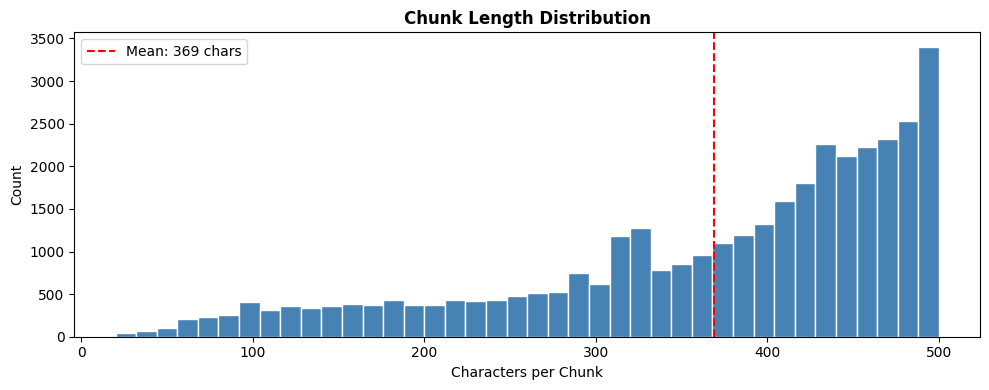

Mean chunk length: 369 chars
Min: 20 | Max: 500


In [7]:
# Chunk length distribution
import matplotlib.pyplot as plt
chunk_lengths = [len(c) for c in chunks]

plt.figure(figsize=(10, 4))
plt.hist(chunk_lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(np.mean(chunk_lengths), color='red', linestyle='--',
            label=f'Mean: {np.mean(chunk_lengths):.0f} chars')
plt.title('Chunk Length Distribution', fontweight='bold')
plt.xlabel('Characters per Chunk')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('chunk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean chunk length: {np.mean(chunk_lengths):.0f} chars')
print(f'Min: {min(chunk_lengths)} | Max: {max(chunk_lengths)}')

## 4. Generate Embeddings

**Model:** `all-MiniLM-L6-v2`

**Justification:**
- Lightweight (80MB) — runs efficiently on CPU
- 384-dimensional embeddings balance speed and quality
- Trained specifically for semantic similarity tasks
- Strong performance on sentence-level retrieval benchmarks
- Widely used in production RAG systems

In [8]:
print('Loading embedding model...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded! Embedding dimension: {model.get_sentence_embedding_dimension()}')

print(f'\nGenerating embeddings for {len(chunks):,} chunks...')
print('This may take 5-10 minutes...')

start = time.time()
embeddings = model.encode(
    chunks,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
elapsed = time.time() - start

print(f'\nDone! Embeddings shape: {embeddings.shape}')
print(f'Time taken: {elapsed/60:.1f} minutes')

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:01<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded! Embedding dimension: 384

Generating embeddings for 35,724 chunks...
This may take 5-10 minutes...


Batches:   0%|          | 0/559 [00:00<?, ?it/s]


Done! Embeddings shape: (35724, 384)
Time taken: 12.1 minutes


## 5. Build FAISS Vector Store

In [9]:
# Normalize embeddings for cosine similarity
embeddings_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

# Build FAISS index
dim = embeddings_norm.shape[1]
index = faiss.IndexFlatIP(dim)  # Inner product = cosine similarity on normalized vectors
index.add(embeddings_norm.astype('float32'))

print(f'FAISS index built!')
print(f'Total vectors indexed: {index.ntotal:,}')
print(f'Embedding dimension: {dim}')

# Save vector store
vs_path = '../vector_store'
os.makedirs(vs_path, exist_ok=True)

faiss.write_index(index, f'{vs_path}/complaints.index')

# Save chunks and metadata
with open(f'{vs_path}/chunks.json', 'w') as f:
    json.dump(chunks, f)

with open(f'{vs_path}/metadata.json', 'w') as f:
    json.dump(chunk_metadata, f)

print(f'\nVector store saved to {vs_path}/')
print(f'Files: complaints.index, chunks.json, metadata.json')

FAISS index built!
Total vectors indexed: 35,724
Embedding dimension: 384

Vector store saved to ../vector_store/
Files: complaints.index, chunks.json, metadata.json


## 6. Test Retrieval

In [10]:
def retrieve(query, k=5, product_filter=None):
    """Retrieve top-k most relevant chunks for a query."""
    q_emb = model.encode([query], convert_to_numpy=True)
    q_emb = q_emb / np.linalg.norm(q_emb)
    scores, indices = index.search(q_emb.astype('float32'), k*3)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        meta = chunk_metadata[idx]
        if product_filter and meta['product_category'] != product_filter:
            continue
        results.append({
            'text': chunks[idx],
            'score': float(score),
            'product': meta['product_category'],
            'issue': meta['issue'],
        })
        if len(results) >= k:
            break
    return results

# Test queries
test_queries = [
    'Why are customers unhappy with credit cards?',
    'What problems do people have with money transfers?',
    'What are the most common personal loan complaints?',
]

for q in test_queries:
    print(f'\n=== Query: {q} ===')
    results = retrieve(q, k=3)
    for i, r in enumerate(results):
        print(f'[{i+1}] ({r["product"]}) Score={r["score"]:.3f}')
        print(f'     {r["text"][:150]}...')


=== Query: Why are customers unhappy with credit cards? ===
[1] (Credit Card) Score=0.697
     . nice thin and non plastic greasy credit. they are obviously and don't like customers. why are they sending new credit cards like this?...
[2] (Credit Card) Score=0.655
     . i had never encountered such a dramatic bad experience with any credit card lender and will not be using credit cards anymore....
[3] (Credit Card) Score=0.632
     . i'm not sure why this credit card company gives me the most hardest time out of all credit card companies. but i think this should be investigated t...

=== Query: What problems do people have with money transfers? ===
[1] (Money Transfer) Score=0.595
     two money transfers were sent via money transfer to a bank account overseas. the money never arrived to the intended recipients. after numerous attemp...
[2] (Money Transfer) Score=0.566
     . they are next to impossible to get a hold of, no one wants to take ownership for anything, i have been transf